# Laboratorio 1 — Series de Tiempo
## 2. Construcción y análisis preliminar de las series
**CC3084 – Data Science · UVG · Semestre II 2026**

Este cuaderno cubre los incisos **2, 3 y el análisis preliminar del 4** (a–e) para el avance:

- **División temporal** entrenamiento/prueba (~70/30).
- **Series construidas** (a partir del entrenamiento):
  - **Obligatoria:** Total mensual de viajeros.
  - **Categoría 1 — Vías de ingreso:** Aérea, Terrestre, Marítima (3 series).
  - **Categoría 2 — Tipo de viajero:** Turista, Excursionista, Viajero, Cruceristas (4 series).
- Para cada serie: **inicio/fin/frecuencia**, **gráfico**, **descomposición**, discusión de
  **estacionariedad en media y varianza**, necesidad de **transformación**, **ACF/PACF** y **prueba ADF**.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ROOT = Path.cwd().parents[1] if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(ROOT / '01_limpieza_eda' / 'src'))
sys.path.append(str(ROOT / '02_series_tiempo' / 'src'))
import config, series
config.aplicar_estilo()
MILES = FuncFormatter(config.miles)
P = config.PALETTE

df = series.cargar_limpio()
print('Datos limpios:', len(df), 'registros,', df['fecha'].nunique(), 'meses')

Datos limpios: 161015 registros, 210 meses


### 2.1 División entrenamiento / prueba (inciso 2)

La división es **temporal** (respeta el orden del tiempo, nunca aleatoria en series de tiempo):
~70% inicial para entrenamiento y ~30% final para prueba. Con 210 meses, el corte queda en **147 meses**.

Total meses: 210
ENTRENAMIENTO: 147 meses  (2009-01-01 → 2021-03-01)
PRUEBA       : 63 meses  (2021-04-01 → 2026-06-01)
Proporción entrenamiento: 70.0%


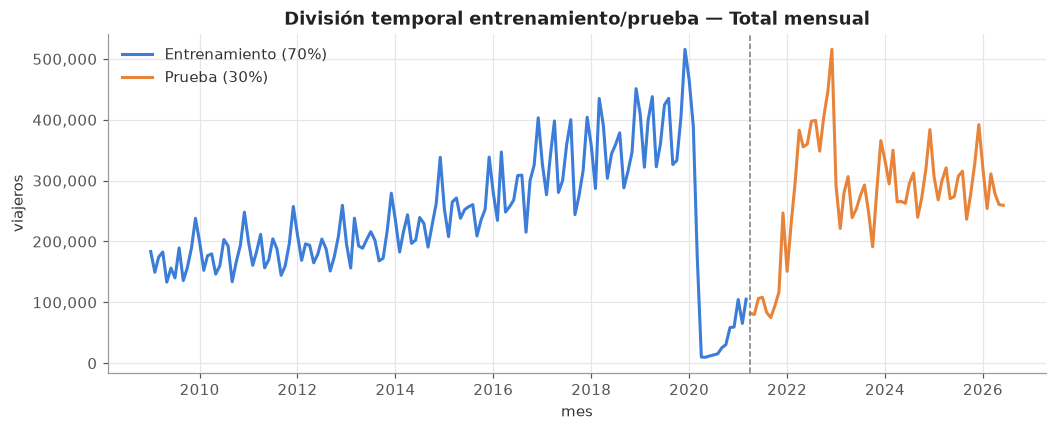

In [2]:
tot = series.serie_mensual(df)                 # serie total mensual
tr, te = series.split_temporal(tot)
print(f'Total meses: {len(tot)}')
print(f'ENTRENAMIENTO: {len(tr)} meses  ({tr.index.min().date()} → {tr.index.max().date()})')
print(f'PRUEBA       : {len(te)} meses  ({te.index.min().date()} → {te.index.max().date()})')
print(f'Proporción entrenamiento: {len(tr)/len(tot):.1%}')

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(tr.index, tr.values, color=P['azul'], label='Entrenamiento (70%)')
ax.plot(te.index, te.values, color=P['naranja'], label='Prueba (30%)')
ax.axvline(te.index.min(), color=P['gris'], ls='--', lw=1)
ax.yaxis.set_major_formatter(MILES)
ax.set_title('División temporal entrenamiento/prueba — Total mensual')
ax.set_xlabel('mes'); ax.set_ylabel('viajeros'); ax.legend()
plt.savefig(config.FIG_DIR / 'ser_split.png'); plt.show()

**Nota importante sobre la división.** El corte del 70% cae en **marzo 2021**: la caída pandémica (2020) queda en
**entrenamiento** y toda la **recuperación** (2021→) queda en **prueba**. Es la división que pide el enunciado, pero
implica que el conjunto de prueba tiene un régimen distinto (post-pandemia y con el cambio de definición de `Viajero`
en 2023); lo tendremos en cuenta al evaluar los modelos en la entrega final.

### 2.2 Construcción de todas las series (inciso 3)

In [3]:
# Serie obligatoria
series_dict = {'Total': tot}

# Categoría 1: Vías de ingreso (3 series)
vias = ['Aérea', 'Terrestre', 'Marítima']
for v in vias:
    series_dict[f'Vía: {v}'] = series.serie_mensual(df, 'Vía', v)

# Categoría 2: Tipo de viajero (todas las categorías existentes)
tipos = list(df['Tipo de Viajero'].value_counts().index)
for t in tipos:
    series_dict[f'Tipo: {t}'] = series.serie_mensual(df, 'Tipo de Viajero', t)

# Resumen inicio/fin/frecuencia de cada serie (inciso 4.a) — sobre entrenamiento
filas = []
for nombre, s in series_dict.items():
    s_tr, _ = series.split_temporal(s)
    r = series.resumen_serie(s_tr)
    r['serie'] = nombre
    r['media_train'] = round(s_tr.mean(), 0)
    filas.append(r)
resumen = pd.DataFrame(filas)[['serie','inicio','fin','frecuencia','n_obs','media_train']]
resumen

,serie,inicio,fin,frecuencia,n_obs,media_train
0,Total,2009-01-01,2021-03-01,Mensual (MS),147,237121.0
1,Vía: Aérea,2009-01-01,2021-03-01,Mensual (MS),147,89141.0
2,Vía: Terrestre,2009-01-01,2021-03-01,Mensual (MS),147,139988.0
3,Vía: Marítima,2009-01-01,2021-03-01,Mensual (MS),147,7991.0
4,Tipo: Turista,2009-01-01,2021-03-01,Mensual (MS),147,175656.0
5,Tipo: Viajero,2009-01-01,2021-03-01,Mensual (MS),147,15594.0
6,Tipo: Excursionista,2009-01-01,2021-03-01,Mensual (MS),147,38562.0
7,Tipo: Cruceristas,2009-01-01,2018-01-01,Mensual (MS),109,7163.0


Todas las series comparten **inicio ene-2009**, **fin mar-2021** (entrenamiento) y **frecuencia mensual (MS)**,
con **147 observaciones**. A continuación analizamos en detalle la serie obligatoria y las series por vía; para las
demás se reporta el gráfico y la prueba ADF.

In [4]:
def analiza_serie(nombre, s, slug, color, transformar=True):
    '''Grafica serie, descomposición, ACF/PACF y ADF (sobre entrenamiento).'''
    s_tr, s_te = series.split_temporal(s)
    print(f'=== {nombre} ===')
    print('Inicio:', s_tr.index.min().date(), '| Fin:', s_tr.index.max().date(),
          '| Frecuencia: Mensual (MS) | n =', len(s_tr))

    # ADF en niveles y en primera diferencia
    adf0 = series.adf_test(s_tr)
    adf1 = series.adf_test(s_tr.diff().dropna())
    print(f"ADF niveles      : stat={adf0['adf_stat']:.2f}  p={adf0['p_value']:.3f}  -> "
          f"{'estacionaria' if adf0['estacionaria_5%'] else 'NO estacionaria'} (5%)")
    print(f"ADF 1a diferencia: stat={adf1['adf_stat']:.2f}  p={adf1['p_value']:.3f}  -> "
          f"{'estacionaria' if adf1['estacionaria_5%'] else 'NO estacionaria'} (5%)")

    # Descomposición multiplicativa (si no hay ceros) o aditiva
    modelo = 'multiplicative' if (s_tr > 0).all() else 'additive'
    dec = seasonal_decompose(s_tr, model=modelo, period=12)
    fig, axs = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
    axs[0].plot(s_tr.index, s_tr.values, color=color); axs[0].set_ylabel('serie')
    axs[0].set_title(f'{nombre} — descomposición {modelo} (período 12)')
    axs[1].plot(dec.trend.index, dec.trend.values, color=P['azul']); axs[1].set_ylabel('tendencia')
    axs[2].plot(dec.seasonal.index, dec.seasonal.values, color=P['verde']); axs[2].set_ylabel('estacional')
    axs[3].scatter(dec.resid.index, dec.resid.values, s=10, color=P['gris']); axs[3].set_ylabel('residuo')
    # Formato de miles solo en paneles a escala de nivel; en multiplicativo
    # estacional/residuo son razones (~1) y no llevan separador de miles.
    axs[0].yaxis.set_major_formatter(MILES); axs[1].yaxis.set_major_formatter(MILES)
    if modelo == 'additive':
        axs[2].yaxis.set_major_formatter(MILES); axs[3].yaxis.set_major_formatter(MILES)
    axs[3].set_xlabel('mes')
    plt.tight_layout(); plt.savefig(config.FIG_DIR / f'ser_{slug}_decomp.png'); plt.show()

    # ACF / PACF
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
    plot_acf(s_tr, lags=36, ax=ax[0], color=color)
    plot_pacf(s_tr, lags=36, ax=ax[1], method='ywm', color=color)
    ax[0].set_title(f'ACF — {nombre}'); ax[1].set_title(f'PACF — {nombre}')
    plt.tight_layout(); plt.savefig(config.FIG_DIR / f'ser_{slug}_acf.png'); plt.show()
    return adf0, adf1

### 2.3 Serie obligatoria — Total mensual (inciso 4.a–e)

=== Total mensual ===
Inicio: 2009-01-01 | Fin: 2021-03-01 | Frecuencia: Mensual (MS) | n = 147
ADF niveles      : stat=-1.97  p=0.300  -> NO estacionaria (5%)
ADF 1a diferencia: stat=-3.21  p=0.020  -> estacionaria (5%)


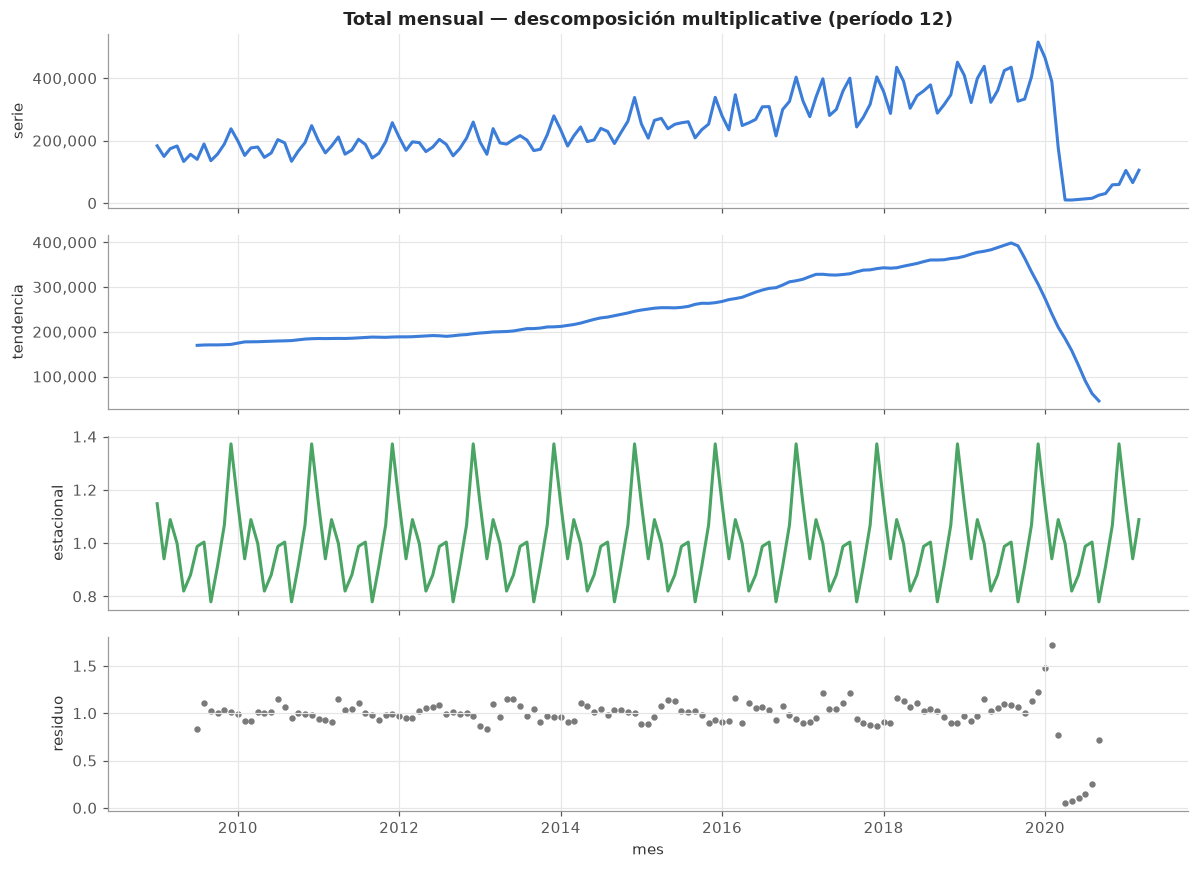

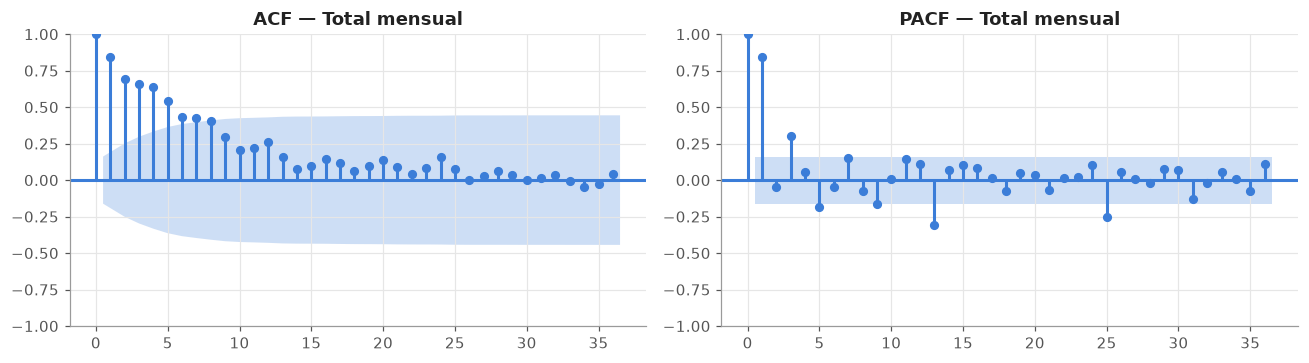

In [5]:
a0, a1 = analiza_serie('Total mensual', tot, 'total', P['azul'])

**Interpretación — Total mensual.**
- **Gráfico (4.b):** tendencia creciente hasta 2020, shock pandémico y arranque de recuperación; oscilación anual marcada.
- **Descomposición (4.c):** hay **tendencia** clara y **estacionalidad de período 12** estable; el residuo se dispara en 2020.
  La **amplitud estacional crece con el nivel** de la serie ⇒ **no estacionaria en varianza**.
- **Transformación (4.d):** conviene una **transformación logarítmica** (o Box-Cox) para estabilizar la varianza antes de modelar.
- **Estacionariedad en media (4.e):** la **ACF decae muy lentamente** (típico de serie con tendencia) ⇒ **no estacionaria en media**.
  La **prueba ADF en niveles no rechaza** la raíz unitaria (p ≈ 0.30), confirmándolo. Tras **una diferenciación** la ADF sí
  rechaza (serie estacionaria), por lo que **d = 1**. La estacionalidad sugiere además una diferencia estacional (D=1, s=12)
  para un modelo SARIMA en la entrega final.

### 2.4 Categoría 1 — Vías de ingreso (Aérea, Terrestre, Marítima)

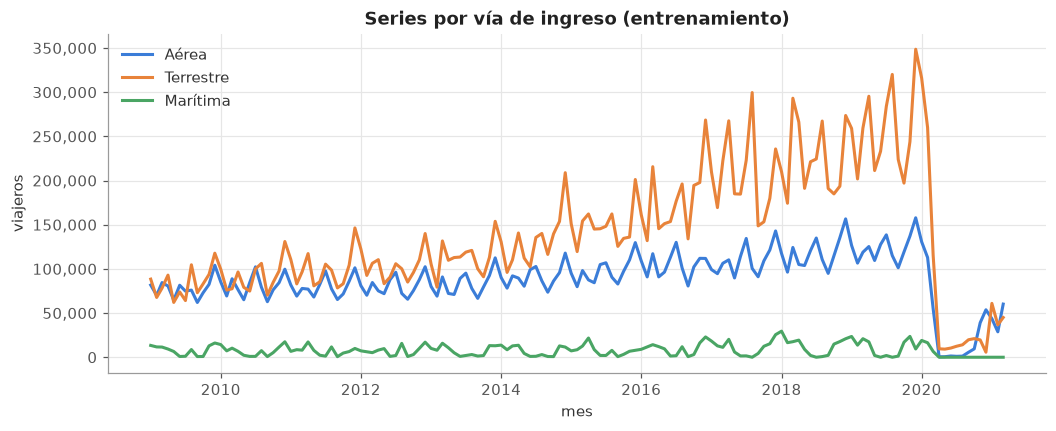

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
for v, color in zip(vias, [P['azul'], P['naranja'], P['verde']]):
    s_tr, _ = series.split_temporal(series_dict[f'Vía: {v}'])
    ax.plot(s_tr.index, s_tr.values, label=v, color=color)
ax.yaxis.set_major_formatter(MILES)
ax.set_title('Series por vía de ingreso (entrenamiento)')
ax.set_xlabel('mes'); ax.set_ylabel('viajeros'); ax.legend()
plt.savefig(config.FIG_DIR / 'ser_vias.png'); plt.show()

=== Vía Aérea ===
Inicio: 2009-01-01 | Fin: 2021-03-01 | Frecuencia: Mensual (MS) | n = 147
ADF niveles      : stat=-2.36  p=0.152  -> NO estacionaria (5%)
ADF 1a diferencia: stat=-4.07  p=0.001  -> estacionaria (5%)


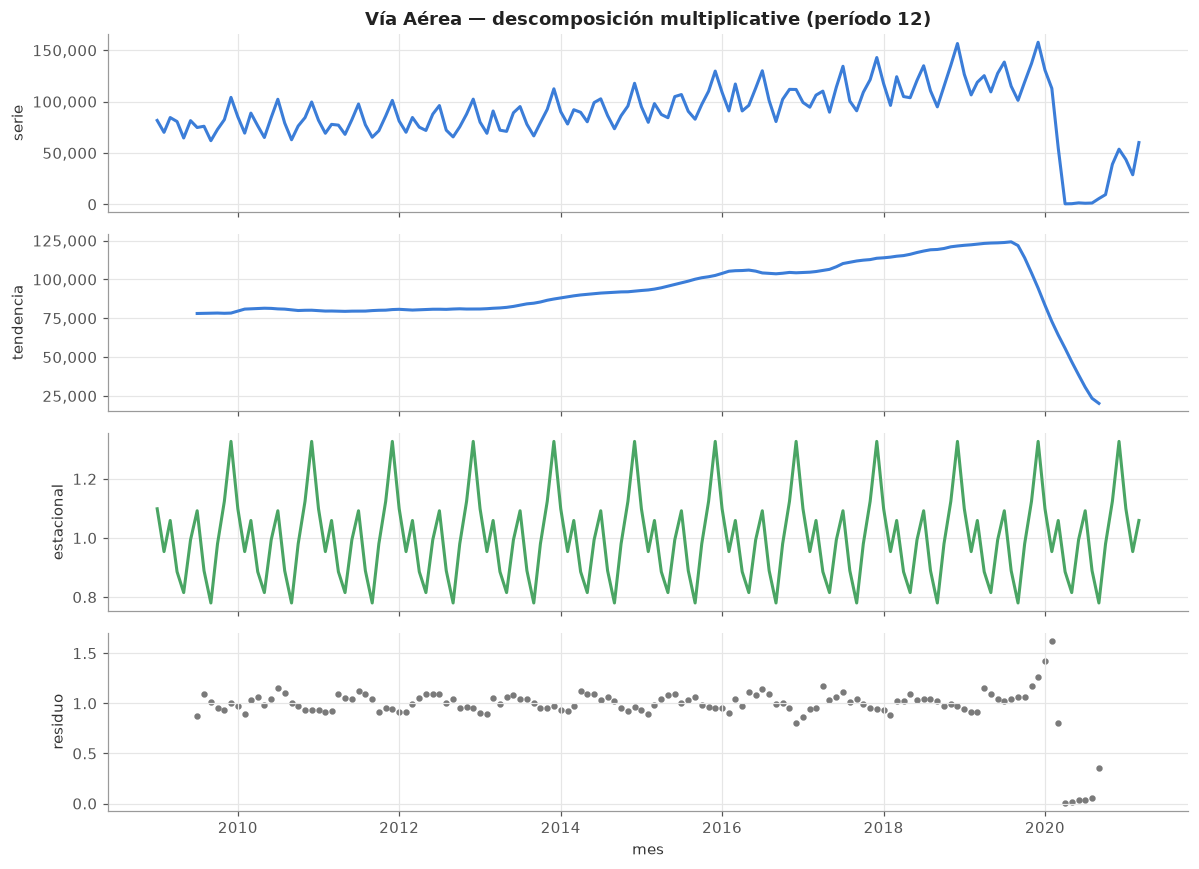

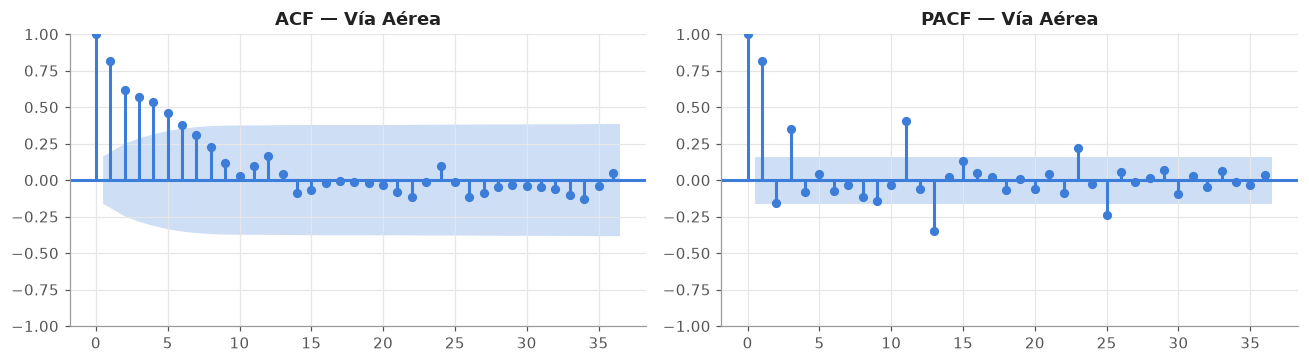

In [7]:
a0, a1 = analiza_serie('Vía Aérea', series_dict['Vía: Aérea'], 'via_aerea', P['azul'])

=== Vía Terrestre ===
Inicio: 2009-01-01 | Fin: 2021-03-01 | Frecuencia: Mensual (MS) | n = 147
ADF niveles      : stat=-1.87  p=0.345  -> NO estacionaria (5%)
ADF 1a diferencia: stat=-3.29  p=0.015  -> estacionaria (5%)


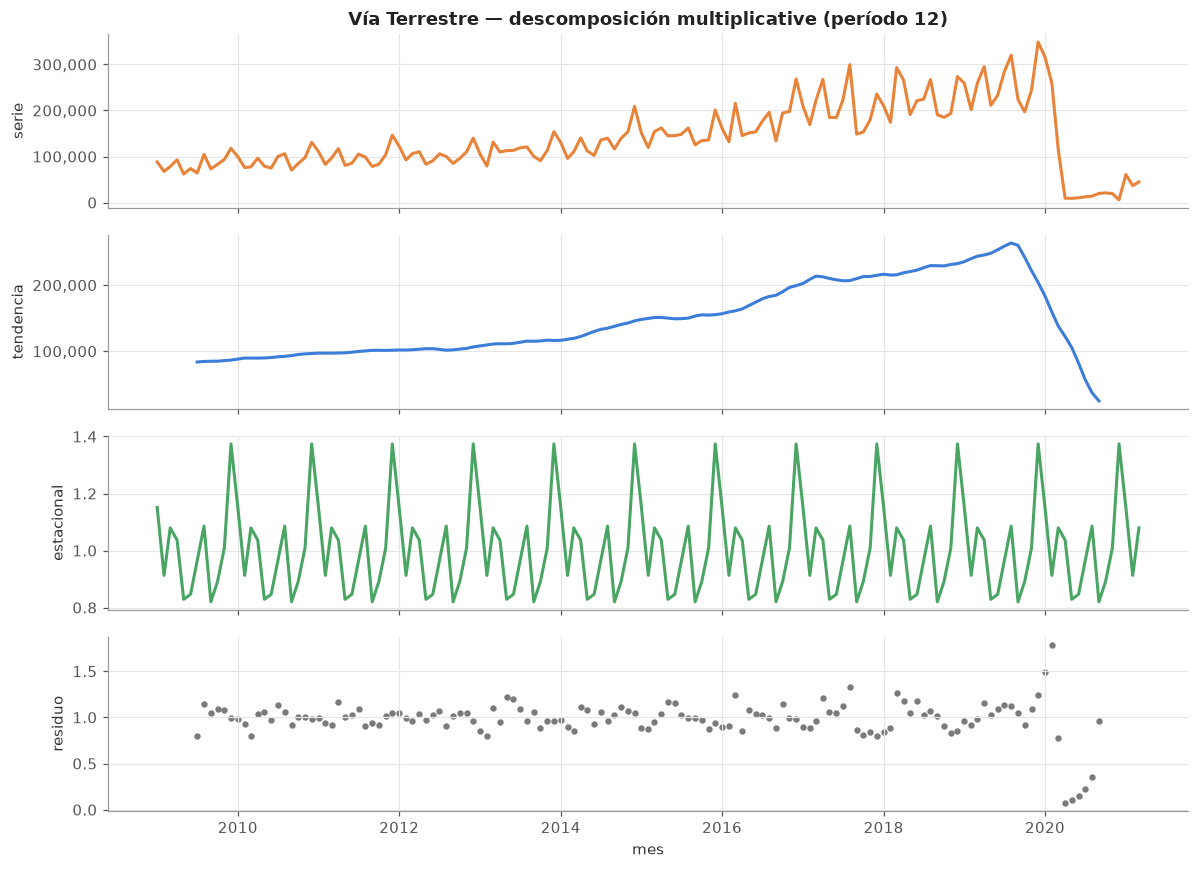

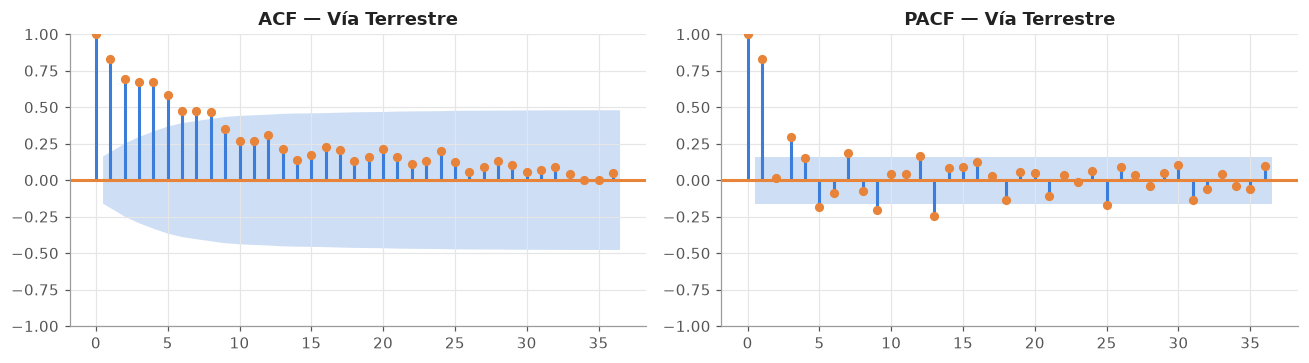

In [8]:
a0, a1 = analiza_serie('Vía Terrestre', series_dict['Vía: Terrestre'], 'via_terrestre', P['naranja'])

**Interpretación — Vías.**
- **Terrestre** aporta el mayor volumen y define la estacionalidad del total; **Aérea** es más estable y de crecimiento sostenido;
  **Marítima** (cruceros) es pequeña e intermitente.
- Ambas (Aérea y Terrestre) muestran **tendencia** y **estacionalidad de período 12**, con **amplitud proporcional al nivel**
  ⇒ **no estacionarias en varianza** (se sugiere log) ni **en media** (ACF de decaimiento lento; ADF no rechaza en niveles,
  sí tras **d = 1**).
- La **Marítima** es más irregular; se analiza con detalle en la entrega final.

### 2.5 Categoría 2 — Tipo de viajero

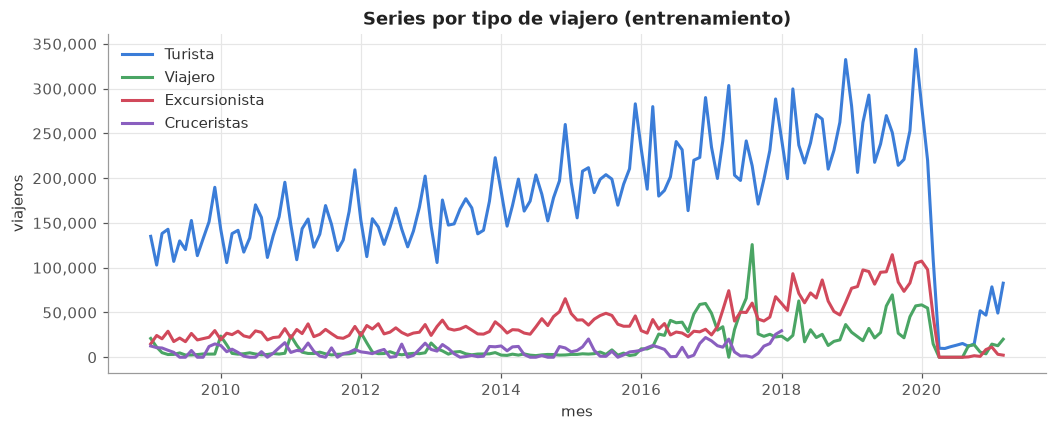

In [9]:
fig, ax = plt.subplots(figsize=(11, 4))
paleta_t = [P['azul'], P['verde'], P['rojo'], P['morado']]
for t, color in zip(tipos, paleta_t):
    s_tr, _ = series.split_temporal(series_dict[f'Tipo: {t}'])
    ax.plot(s_tr.index, s_tr.values, label=t, color=color)
ax.yaxis.set_major_formatter(MILES)
ax.set_title('Series por tipo de viajero (entrenamiento)')
ax.set_xlabel('mes'); ax.set_ylabel('viajeros'); ax.legend()
plt.savefig(config.FIG_DIR / 'ser_tipos.png'); plt.show()

In [10]:
# Tabla ADF resumen para las 4 series de tipo de viajero
filas = []
for t in tipos:
    s_tr, _ = series.split_temporal(series_dict[f'Tipo: {t}'])
    adf0 = series.adf_test(s_tr)
    adf1 = series.adf_test(s_tr.diff().dropna())
    filas.append({'serie': f'Tipo: {t}',
                  'ADF_niveles_p': round(adf0['p_value'], 3),
                  'estac_niveles': adf0['estacionaria_5%'],
                  'ADF_diff1_p': round(adf1['p_value'], 3),
                  'estac_diff1': adf1['estacionaria_5%']})
pd.DataFrame(filas)

,serie,ADF_niveles_p,estac_niveles,ADF_diff1_p,estac_diff1
0,Tipo: Turista,0.227,False,0.086,False
1,Tipo: Viajero,0.232,False,0.000,True
2,Tipo: Excursionista,0.232,False,0.000,True
3,Tipo: Cruceristas,0.987,False,0.000,True


=== Tipo: Turista ===
Inicio: 2009-01-01 | Fin: 2021-03-01 | Frecuencia: Mensual (MS) | n = 147
ADF niveles      : stat=-2.14  p=0.227  -> NO estacionaria (5%)
ADF 1a diferencia: stat=-2.64  p=0.086  -> NO estacionaria (5%)


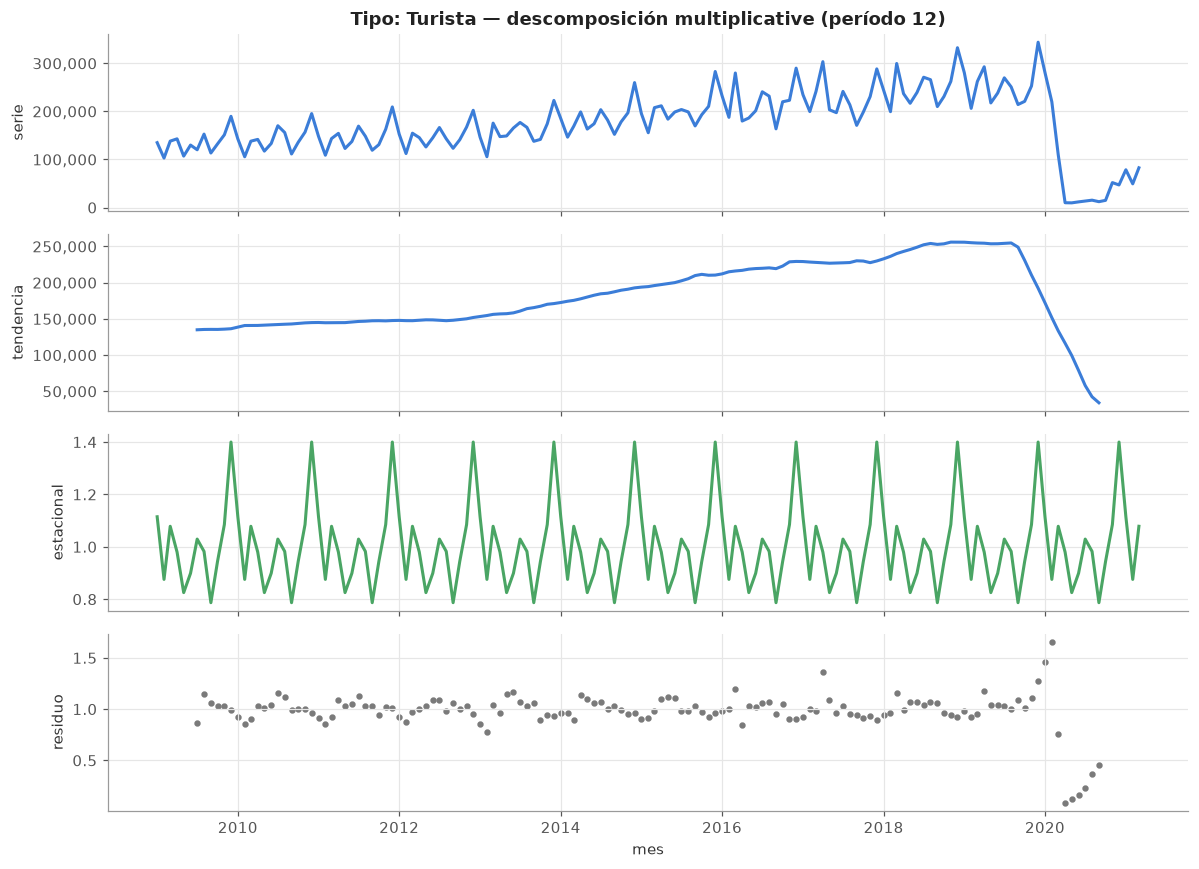

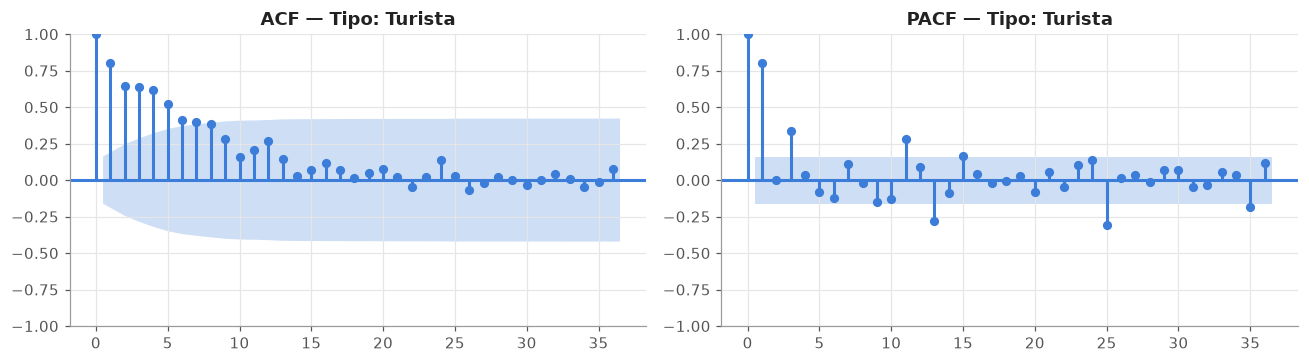

In [11]:
a0, a1 = analiza_serie('Tipo: Turista', series_dict['Tipo: Turista'], 'tipo_turista', P['azul'])

**Interpretación — Tipo de viajero.**
- **Turista** es la serie de mayor volumen y con estacionalidad/tendencia claras; **Excursionista** la acompaña.
- La serie **Viajero** presenta el problema documentado: su definición cambia en 2023 (quiebre de nivel), por lo que
  su comparación de largo plazo es delicada.
- Para **Turista** la evidencia coincide con las demás: **no estacionaria en media ni en varianza**, requiere
  **log** y **d = 1** (más componente estacional s=12).

## Conclusiones preliminares del avance

1. La **división 70/30 temporal** deja el shock pandémico en entrenamiento y la recuperación en prueba (algo a considerar al modelar).
2. **Todas las series analizadas** (Total, Aérea, Terrestre, Turista) comparten el mismo diagnóstico:
   **tendencia**, **estacionalidad de período 12** y **varianza creciente con el nivel**.
3. En consecuencia: **no son estacionarias en varianza** (⇒ transformación **logarítmica**/Box-Cox) ni **en media**
   (ACF de decaimiento lento y **ADF no rechaza** en niveles; se vuelven estacionarias con **d = 1**).
4. Los parámetros de partida para la entrega final serán del tipo **SARIMA(p, 1, q)(P, 1, Q)₁₂**, afinando *p, q, P, Q*
   con las funciones **ACF/PACF** y comparando por **AIC/BIC**, frente a **Holt-Winters, suavizamiento exponencial,
   seasonal naïve y Prophet**.